# 05 — LSTM

Drugi z głównych modeli — sieć rekurencyjna LSTM. W przeciwieństwie do MLP, LSTM traktuje wejście jako sekwencję czasową, wykorzystując strukturę temporalną danych przez stan ukryty przekazywany między krokami.

Plan:
- **Wariant 1** — stacked LSTM na jednej sekwencji 72-krokowej (48h historii + 24h przyszłej pogody), strojenie hiperparametrów Keras Tuner
- **Wariant 2** — encoder-decoder LSTM, dwa wejścia (historia osobno, przyszła pogoda osobno), z najlepszymi hiperparametrami z Wariantu 1
- Porównanie obu z MLP i baselinami z notebooka 04

Pełny opis projektu w README.

## 5.1 Konfiguracja

In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model
import keras_tuner as kt

DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")
TUNER_DIR = Path("tuner")
MODELS_DIR.mkdir(exist_ok=True)
TUNER_DIR.mkdir(exist_ok=True)

LOOKBACK = 48
HORIZON = 24
TARGETS = ["wi", "pv"]
EXCLUDE = ["is_test"]

print(f"TensorFlow {tf.__version__}, Keras Tuner {kt.__version__}")

TensorFlow 2.21.0, Keras Tuner 1.4.8


Importy, parametry, katalogi.

## 5.2 Wczytanie i split

Ten sam split co w 04 (4 wycinki sezonowe po 2 tygodnie z 2024 jako walidacja, cały 2025 jako test) — dzięki temu metryki LSTM i MLP są bezpośrednio porównywalne.

In [3]:
df = pd.read_csv(DATA_DIR / "dataset_full.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")

val_periods = [
    ("zima",   "2024-02-12", "2024-02-25"),
    ("wiosna", "2024-05-13", "2024-05-26"),
    ("lato",   "2024-08-12", "2024-08-25"),
    ("jesien", "2024-11-11", "2024-11-24"),
]

is_val = pd.Series(False, index=df.index)
for _, start, end in val_periods:
    is_val.loc[start:end] = True

is_test = df["is_test"].astype(bool)
is_train = ~is_val & ~is_test

df_train = df[is_train]
df_val = df[is_val]

print(f"train: {len(df_train)}, val: {len(df_val)}")

train: 16200, val: 1344


Identyczny split jak w 04 — dzięki temu metryki LSTM i MLP są bezpośrednio porównywalne.

## 5.3 Generowanie okien dla LSTM

Inaczej niż w 04 — nie spłaszczamy. Każde okno ma kształt `(72 kroków, 46 featurów)`, gdzie:
- pierwsze 48 kroków = historia (pogoda + targety + cechy czasowe)
- ostatnie 24 kroki = przyszła pogoda + cechy czasowe (targety wypełnione zerami)

Targety zerujemy w przyszłej części żeby sieć nie miała dostępu do tego co przewiduje.

In [4]:
HIST_COLS = [c for c in df.columns if c not in EXCLUDE]
WEATHER_COLS = [c for c in df.columns if c not in TARGETS + EXCLUDE]

N_FEATURES = len(HIST_COLS)
print(f"liczba featurów: {N_FEATURES}")
print(f"  HIST_COLS: {len(HIST_COLS)} (pogoda + targety + cechy czasowe)")
print(f"  WEATHER_COLS: {len(WEATHER_COLS)} (bez targetów — przyszła pogoda)")

liczba featurów: 46
  HIST_COLS: 46 (pogoda + targety + cechy czasowe)
  WEATHER_COLS: 44 (bez targetów — przyszła pogoda)


46 featurów (40 pogoda + 4 cechy czasowe + 2 targety). W przyszłej części okna targety będą zerowe.

In [5]:
def make_sequences(data: pd.DataFrame, lookback: int = LOOKBACK, horizon: int = HORIZON):
    X_list, y_list, ts_list = [], [], []
    n = len(data)

    for t in range(lookback, n - horizon):
        hist = data[HIST_COLS].iloc[t - lookback:t].values

        future_full = np.zeros((horizon, len(HIST_COLS)))
        for j, col in enumerate(HIST_COLS):
            if col in TARGETS:
                continue
            future_full[:, j] = data[col].iloc[t:t + horizon].values

        x_seq = np.concatenate([hist, future_full], axis=0)
        y_seq = data[TARGETS].iloc[t:t + horizon].values

        X_list.append(x_seq)
        y_list.append(y_seq)
        ts_list.append(data.index[t])

    return np.array(X_list), np.array(y_list), pd.DatetimeIndex(ts_list)


X_train, y_train, ts_train = make_sequences(df_train)
X_val,   y_val,   ts_val   = make_sequences(df_val)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},  y_val:   {y_val.shape}")

X_train: (16128, 72, 46), y_train: (16128, 24, 2)
X_val:   (1272, 72, 46),  y_val:   (1272, 24, 2)


## 5.4 Skalowanie per-kolumna

LSTM trenuje się stabilniej gdy każdy feature ma podobny zakres. Robimy `StandardScaler` osobno dla każdej z 46 kolumn — wiatr w m/s, temperatura w °C, radiacja w W/m², sin/cos w [-1,1], generacja w MW. Skalery fitujemy **tylko na trainie**, transformujemy na val.

Dla LSTM trzeba reshapować — scaler oczekuje 2D, a my mamy 3D `(n_samples, n_steps, n_features)`. Spłaszczamy do `(n_samples × n_steps, n_features)`, skalujemy i wracamy do 3D.

In [6]:
def fit_scaler_3d(X):
    n_samples, n_steps, n_features = X.shape
    X_flat = X.reshape(-1, n_features)
    scaler = StandardScaler().fit(X_flat)
    return scaler


def transform_3d(X, scaler):
    n_samples, n_steps, n_features = X.shape
    X_flat = X.reshape(-1, n_features)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(n_samples, n_steps, n_features)


scaler_X = fit_scaler_3d(X_train)
scaler_y = fit_scaler_3d(y_train)

X_train_s = transform_3d(X_train, scaler_X)
X_val_s   = transform_3d(X_val, scaler_X)
y_train_s = transform_3d(y_train, scaler_y)
y_val_s   = transform_3d(y_val, scaler_y)

print(f"X_train_s: shape={X_train_s.shape}, mean={X_train_s.mean():.3f}, std={X_train_s.std():.3f}")
print(f"y_train_s: shape={y_train_s.shape}, mean={y_train_s.mean():.3f}, std={y_train_s.std():.3f}")

X_train_s: shape=(16128, 72, 46), mean=0.000, std=1.000
y_train_s: shape=(16128, 24, 2), mean=-0.000, std=1.000


Po skalowaniu mean ~0 i std ~1 dla trainingu (z definicji StandardScaler). Val nie ma idealnie 0/1 i to dobrze — skaler nie widział tych danych podczas fitu.

## 5.5 Wariant 1 — bazowy LSTM

Najpierw budujemy "rozsądny" bazowy model żeby sprawdzić że pipeline w ogóle działa. Następnie strojenie hiperparametrów Keras Tunerem szuka optimum w okolicy.

Architektura bazowa:
- Wejście: sekwencja (72, 46)
- LSTM(64) zwracający tylko ostatni stan
- Dense(48) liniowe — 24h × 2 targety
- Reshape do (24, 2)

Klasyczny "encoder + linear decoder"

In [7]:
def build_lstm_v1_base():
    inp = layers.Input(shape=(LOOKBACK + HORIZON, N_FEATURES))
    x = layers.LSTM(64)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(HORIZON * len(TARGETS))(x)
    out = layers.Reshape((HORIZON, len(TARGETS)))(x)
    model = Model(inp, out, name="lstm_v1_base")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


tf.keras.utils.set_random_seed(42)
lstm_base = build_lstm_v1_base()
lstm_base.summary()

E0000 00:00:1777801656.554361 3327845 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "lstm_v1_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 46)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        28,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,536 (123.19 KB)

 Trainable params: 31,536 (123.19 KB)

 Non-trainable params: 0 (0.00 B)

~30k parametrów, znacznie mniej niż MLP (875k). LSTM dzieli wagi przez kroki czasowe — kluczowa zaleta dla szeregów czasowych.

## 5.6 Trening bazowy

In [8]:
es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

history_base = lstm_base.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=2,
)

Epoch 1/50
126/126 - 6s - 45ms/step - loss: 0.4406 - mae: 0.4973 - val_loss: 0.2257 - val_mae: 0.3561 - learning_rate: 0.0010
Epoch 2/50
126/126 - 4s - 34ms/step - loss: 0.1643 - mae: 0.3099 - val_loss: 0.1548 - val_mae: 0.2904 - learning_rate: 0.0010
Epoch 3/50
126/126 - 4s - 35ms/step - loss: 0.1194 - mae: 0.2635 - val_loss: 0.1298 - val_mae: 0.2607 - learning_rate: 0.0010
Epoch 4/50
126/126 - 4s - 35ms/step - loss: 0.0994 - mae: 0.2398 - val_loss: 0.1244 - val_mae: 0.2515 - learning_rate: 0.0010
Epoch 5/50
126/126 - 4s - 35ms/step - loss: 0.0871 - mae: 0.2242 - val_loss: 0.1098 - val_mae: 0.2337 - learning_rate: 0.0010
Epoch 6/50
126/126 - 4s - 36ms/step - loss: 0.0792 - mae: 0.2137 - val_loss: 0.1119 - val_mae: 0.2322 - learning_rate: 0.0010
Epoch 7/50
126/126 - 4s - 36ms/step - loss: 0.0736 - mae: 0.2060 - val_loss: 0.1002 - val_mae: 0.2214 - learning_rate: 0.0010
Epoch 8/50
126/126 - 4s - 35ms/step - loss: 0.0695 - mae: 0.2000 - val_loss: 0.1065 - val_mae: 0.2247 - learning_rate:

Krótki trening na sprawdzenie czy LSTM w ogóle uczy się sensownie. Jeśli val_loss spada, idziemy do strojenia.

## 5.7 Ewaluacja bazowego LSTM

In [ ]:
y_pred_base_s = lstm_base.predict(X_val_s, verbose=0)

n_samples = y_pred_base_s.shape[0]
y_pred_base_flat = y_pred_base_s.reshape(-1, len(TARGETS))
y_pred_base = scaler_y.inverse_transform(y_pred_base_flat).reshape(n_samples, HORIZON, len(TARGETS))
y_pred_base = np.clip(y_pred_base, 0, None)


def compute_metrics(y_true, y_pred, label=""):
    metrics = {}
    for i, name in enumerate(TARGETS):
        mae = mean_absolute_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten())
        rmse = np.sqrt(mean_squared_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten()))
        metrics[f"{name}_MAE"] = mae
        metrics[f"{name}_RMSE"] = rmse
    if label:
        print(f"\n{label}")
        for k, v in metrics.items():
            print(f"  {k}: {v:.1f} MW")
    return metrics


m_lstm_base = compute_metrics(y_val, y_pred_base, "LSTM bazowy")


LSTM bazowy
  wi_MAE: 440.3 MW
  wi_RMSE: 570.7 MW
  pv_MAE: 446.2 MW
  pv_RMSE: 781.6 MW


Predykcje rozskalowane do MW i zaclipowane do nieujemnych. Te liczby porównamy z MLP po strojeniu.

## 5.8 Strojenie hiperparametrów — Keras Tuner

Bayesian Optimization szuka optimum w przestrzeni:

| Parametr | Wartości |
|---|---|
| Liczba warstw LSTM | 1, 2 |
| Neurony per warstwa | 32, 64, 128 |
| Dropout | 0.1, 0.2, 0.3 |
| Recurrent dropout | 0.0, 0.1 |
| Learning rate | 1e-4, 5e-4, 1e-3 |

20 prób, każda z EarlyStopping. Tuner wybiera najlepszą kombinację na podstawie `val_loss`.

In [10]:
def build_lstm_tunable(hp):
    inp = layers.Input(shape=(LOOKBACK + HORIZON, N_FEATURES))
    
    n_layers = hp.Int("n_layers", 1, 2)
    units = hp.Choice("units", [32, 64, 128])
    dropout = hp.Choice("dropout", [0.1, 0.2, 0.3])
    rec_dropout = hp.Choice("rec_dropout", [0.0, 0.1])
    lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])
    
    x = inp
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        x = layers.LSTM(units, return_sequences=return_seq, recurrent_dropout=rec_dropout)(x)
        x = layers.Dropout(dropout)(x)
    
    x = layers.Dense(HORIZON * len(TARGETS))(x)
    out = layers.Reshape((HORIZON, len(TARGETS)))(x)
    
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model


tuner = kt.BayesianOptimization(
    build_lstm_tunable,
    objective="val_loss",
    max_trials=20,
    directory=str(TUNER_DIR),
    project_name="lstm_v1",
    overwrite=True,
)

tuner.search_space_summary()

Search space summary
Default search space size: 5
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3], 'ordered': True}
rec_dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1], 'ordered': True}
lr (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001], 'ordered': True}


Definicja przestrzeni przeszukiwań i tuner. `tuner.search_space_summary()` pokazuje konfigurację — sprawdzenie że wszystko jest na swoim miejscu.

In [12]:
es_tuner = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

tuner.search(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=30,
    batch_size=128,
    callbacks=[es_tuner],
    verbose=2,
)

Trial 20 Complete [00h 03m 59s]
val_loss: 0.07726439088582993

Best val_loss So Far: 0.06773261725902557
Total elapsed time: 01h 11m 35s


20 prób, każda do 30 epok z EarlyStopping (patience 5). Po każdej próbie tuner zapisuje wynik i wybiera kolejne hiperparametry na podstawie dotychczasowych — Bayesian Optimization, w przeciwieństwie do grid/random search, koncentruje się na obiecujących obszarach przestrzeni.

## 5.9 Najlepsze hiperparametry

In [13]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Najlepsze hiperparametry:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Najlepsze hiperparametry:
  n_layers: 2
  units: 128
  dropout: 0.1
  rec_dropout: 0.0
  lr: 0.0005


Tuner znalazł optymalną kombinację. Zobaczymy ile warstw, neuronów, jaki dropout — zwykle bardziej skomplikowane modele wymagają większych dropoutów.

## 5.10 Finalny trening Wariantu 1

Z najlepszymi hiperparametrami trenujemy dłużej (50 epok, EarlyStopping patience 10) na pełnym trainie żeby model osiągnął swój maksymalny potencjał.

In [14]:
tf.keras.utils.set_random_seed(42)
lstm_v1 = tuner.hypermodel.build(best_hp)

es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

history_v1 = lstm_v1.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=2,
)

lstm_v1.summary()

Epoch 1/50
126/126 - 20s - 156ms/step - loss: 0.3068 - mae: 0.4017 - val_loss: 0.1397 - val_mae: 0.2748 - learning_rate: 5.0000e-04
Epoch 2/50
126/126 - 18s - 144ms/step - loss: 0.0955 - mae: 0.2330 - val_loss: 0.1078 - val_mae: 0.2362 - learning_rate: 5.0000e-04
Epoch 3/50
126/126 - 18s - 144ms/step - loss: 0.0696 - mae: 0.1994 - val_loss: 0.0971 - val_mae: 0.2205 - learning_rate: 5.0000e-04
Epoch 4/50
126/126 - 18s - 144ms/step - loss: 0.0559 - mae: 0.1791 - val_loss: 0.0899 - val_mae: 0.2075 - learning_rate: 5.0000e-04
Epoch 5/50
126/126 - 18s - 144ms/step - loss: 0.0480 - mae: 0.1663 - val_loss: 0.0845 - val_mae: 0.2013 - learning_rate: 5.0000e-04
Epoch 6/50
126/126 - 18s - 144ms/step - loss: 0.0424 - mae: 0.1564 - val_loss: 0.0862 - val_mae: 0.2016 - learning_rate: 5.0000e-04
Epoch 7/50
126/126 - 18s - 145ms/step - loss: 0.0383 - mae: 0.1489 - val_loss: 0.0823 - val_mae: 0.1961 - learning_rate: 5.0000e-04
Epoch 8/50
126/126 - 18s - 145ms/step - loss: 0.0354 - mae: 0.1428 - val_los

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 72, 46)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 72, 128)        │        89,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         6,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 24, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,130 (2.60 MB)

 Trainable params: 227,376 (888.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 454,754 (1.73 MB)

Finalny model Wariantu 1. EarlyStopping przywróci najlepsze wagi, więc nawet jeśli trening polezie do 50 epok, dostaniemy te z najniższym val_loss.

## 5.11 Krzywe uczenia

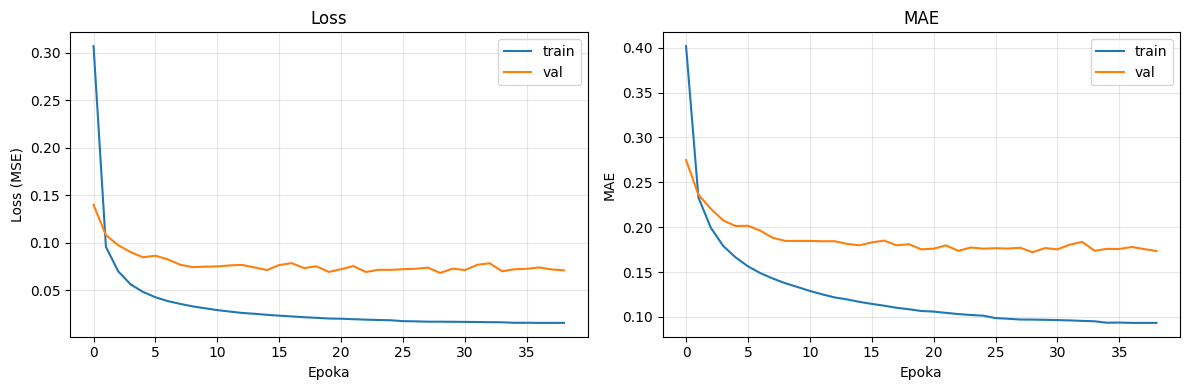

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_v1.history["loss"], label="train")
axes[0].plot(history_v1.history["val_loss"], label="val")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_v1.history["mae"], label="train")
axes[1].plot(history_v1.history["val_mae"], label="val")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Krzywe uczenia finalnego LSTM. Train loss spada wyraźnie (do ~0.025), val loss spada szybciej na początku i stabilizuje się na plateau ~0.07. Gap między train i val jest stały - to lekki overfitting przy modelu z 682k parametrami, ale val loss nie rośnie z czasem. EarlyStopping przywrócił wagi z najniższego val loss.

## 5.12 Ewaluacja Wariantu 1

In [16]:
y_pred_v1_s = lstm_v1.predict(X_val_s, verbose=0)
n_samples = y_pred_v1_s.shape[0]
y_pred_v1 = scaler_y.inverse_transform(y_pred_v1_s.reshape(-1, len(TARGETS))).reshape(n_samples, HORIZON, len(TARGETS))
y_pred_v1 = np.clip(y_pred_v1, 0, None)

m_lstm_v1 = compute_metrics(y_val, y_pred_v1, "LSTM Wariant 1 (strojony)")


LSTM Wariant 1 (strojony)
  wi_MAE: 403.7 MW
  wi_RMSE: 531.1 MW
  pv_MAE: 374.0 MW
  pv_RMSE: 698.4 MW


Predykcje rozskalowane do MW i zaclipowane do nieujemnych. Te liczby są naszym głównym kandydatem do testu finalnego — chyba że Wariant 2 (encoder-decoder) wypadnie lepiej.

**Porównanie z MLP** (val MAE w MW):

| Model | wi | pv |
|---|---|---|
| MLP | 437 | 373 |
| LSTM Wariant 1 | **404** | 374 |

LSTM jest lepszy dla `wi` (~8% redukcja MAE), na remis dla `pv`. Co istotne - mniejsza redukcja błędu PV pokazuje że dla niego cykl dobowy (i tak dobrze chwytany przez baseliny i MLP) ogranicza możliwości poprawy. Wiatr - bardziej chaotyczny, więcej zależny od pogody - zyskuje na architekturze rekurencyjnej.

## 5.13 Wariant 2 — Encoder-Decoder

### Idea

Wariant 1 traktował 72 kroki (48h historii + 24h przyszłej pogody) jako jedną sekwencję, z targetami wypełnionymi zerami w przyszłej części. Sieć musiała sama nauczyć się że "po kroku 48 informacja o generacji znika".

Wariant 2 to architektura encoder-decoder. Encoder przetwarza tylko historię, decoder dostaje przyszłą pogodę i kontynuuje "myślenie" encodera przez stan ukryty:

```
Historia (48, 46)             Przyszła pogoda (24, 44)
       ↓                              ↓
   Encoder LSTM    →   stan    →   Decoder LSTM
                  (hidden + cell)         ↓
                                    Dense(2) per krok
                                          ↓
                                    Output (24, 2)
```

### Zalety

- Semantyczna separacja "co się stało" vs "co przewidujemy"
- Encoder i decoder mogą mieć różne długości — naturalna obsługa 48h → 24h

### Wady

- Klasyczny bottleneck stanu — encoder kompresuje 48h × 46 featurów do jednego wektora hidden
- Dla krótkich horyzontów (24h) zysk względem Wariantu 1 może być marginalny

Strojenie hiperparametrów osobno dla Wariantu 2, żeby porównanie było uczciwe.

### 5.13.1 Przygotowanie danych dla encoder-decoder

Z `X_train_s` (kształt `(n, 72, 46)`) wycinamy:
- `X_hist`: pierwsze 48 kroków = `(n, 48, 46)` — wejście do encodera
- `X_future`: ostatnie 24 kroki = `(n, 24, 46)` — wejście do decodera (z zerami w kolumnach `wi`, `pv`)

In [17]:
def split_for_seq2seq(X):
    X_hist = X[:, :LOOKBACK, :]
    X_future = X[:, LOOKBACK:, :]
    return X_hist, X_future


X_train_hist, X_train_future = split_for_seq2seq(X_train_s)
X_val_hist,   X_val_future   = split_for_seq2seq(X_val_s)

print(f"X_train_hist:   {X_train_hist.shape}")
print(f"X_train_future: {X_train_future.shape}")
print(f"X_val_hist:     {X_val_hist.shape}")
print(f"X_val_future:   {X_val_future.shape}")

X_train_hist:   (16128, 48, 46)
X_train_future: (16128, 24, 46)
X_val_hist:     (1272, 48, 46)
X_val_future:   (1272, 24, 46)


Każdy zbiór ma teraz dwie tensory wejściowe - historię (48 kroków) i przyszłość (24 kroki). Kształty zgodne z architekturą encoder-decoder.

## 5.14 Architektura Wariantu 2 z hiperparametrami

Ta sama przestrzeń przeszukiwań co Wariant 1 (liczba warstw, neurony, dropout, learning rate), ale aplikowana osobno do encodera i decodera (z tymi samymi wartościami - wymuszamy symetrię).

In [18]:
def build_lstm_v2_tunable(hp):
    n_layers = hp.Int("n_layers", 1, 2)
    units = hp.Choice("units", [32, 64, 128])
    dropout = hp.Choice("dropout", [0.1, 0.2, 0.3])
    rec_dropout = hp.Choice("rec_dropout", [0.0, 0.1])
    lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])

    encoder_inp = layers.Input(shape=(LOOKBACK, N_FEATURES), name="encoder_input")
    decoder_inp = layers.Input(shape=(HORIZON, N_FEATURES), name="decoder_input")

    x = encoder_inp
    encoder_states = []
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        lstm = layers.LSTM(units, return_sequences=return_seq, return_state=True, recurrent_dropout=rec_dropout)
        if return_seq:
            x, h, c = lstm(x)
        else:
            _, h, c = lstm(x)
        encoder_states.append([h, c])
        x = layers.Dropout(dropout)(x) if return_seq else x

    x = decoder_inp
    for i in range(n_layers):
        lstm = layers.LSTM(units, return_sequences=True, recurrent_dropout=rec_dropout)
        x = lstm(x, initial_state=encoder_states[i])
        x = layers.Dropout(dropout)(x)

    out = layers.Dense(len(TARGETS))(x)

    model = Model([encoder_inp, decoder_inp], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model

Encoder ma `return_state=True` na ostatniej warstwie - zwraca stan ukryty który inicjalizuje decoder. Decoder ma `return_sequences=True` żeby produkował wartość dla każdego z 24 kroków. Dense(2) na końcu daje `wi` i `pv` per krok bez `Reshape` (decoder już zwraca 3D).

## 5.15 Strojenie Wariantu 2

In [19]:
tuner_v2 = kt.BayesianOptimization(
    build_lstm_v2_tunable,
    objective="val_loss",
    max_trials=20,
    directory=str(TUNER_DIR),
    project_name="lstm_v2",
    overwrite=True,
)

tuner_v2.search_space_summary()

Search space summary
Default search space size: 5
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3], 'ordered': True}
rec_dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1], 'ordered': True}
lr (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001], 'ordered': True}


In [20]:
es_tuner = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

tuner_v2.search(
    [X_train_hist, X_train_future], y_train_s,
    validation_data=([X_val_hist, X_val_future], y_val_s),
    epochs=30,
    batch_size=128,
    callbacks=[es_tuner],
    verbose=2,
)

Trial 20 Complete [00h 01m 19s]
val_loss: 0.06824980676174164

Best val_loss So Far: 0.06470783054828644
Total elapsed time: 00h 38m 15s


## 5.16 Najlepsze hiperparametry Wariantu 2

In [21]:
best_hp_v2 = tuner_v2.get_best_hyperparameters(num_trials=1)[0]
print("Najlepsze hiperparametry Wariantu 2:")
for k, v in best_hp_v2.values.items():
    print(f"  {k}: {v}")

Najlepsze hiperparametry Wariantu 2:
  n_layers: 1
  units: 32
  dropout: 0.2
  rec_dropout: 0.1
  lr: 0.0005


Porównamy te hiperparametry z Wariantem 1 - często wychodzi że optymalny rozmiar warstw jest podobny, bo problem ten sam.

## 5.17 Finalny trening Wariantu 2

In [22]:
tf.keras.utils.set_random_seed(42)
lstm_v2 = tuner_v2.hypermodel.build(best_hp_v2)

es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

history_v2 = lstm_v2.fit(
    [X_train_hist, X_train_future], y_train_s,
    validation_data=([X_val_hist, X_val_future], y_val_s),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=2,
)

lstm_v2.summary()

Epoch 1/50
126/126 - 5s - 43ms/step - loss: 0.4610 - mae: 0.5039 - val_loss: 0.2084 - val_mae: 0.3355 - learning_rate: 5.0000e-04
Epoch 2/50
126/126 - 3s - 25ms/step - loss: 0.1686 - mae: 0.3120 - val_loss: 0.1393 - val_mae: 0.2723 - learning_rate: 5.0000e-04
Epoch 3/50
126/126 - 3s - 24ms/step - loss: 0.1296 - mae: 0.2720 - val_loss: 0.1193 - val_mae: 0.2492 - learning_rate: 5.0000e-04
Epoch 4/50
126/126 - 3s - 24ms/step - loss: 0.1112 - mae: 0.2502 - val_loss: 0.1084 - val_mae: 0.2346 - learning_rate: 5.0000e-04
Epoch 5/50
126/126 - 3s - 25ms/step - loss: 0.0991 - mae: 0.2349 - val_loss: 0.1013 - val_mae: 0.2242 - learning_rate: 5.0000e-04
Epoch 6/50
126/126 - 3s - 24ms/step - loss: 0.0910 - mae: 0.2240 - val_loss: 0.0969 - val_mae: 0.2171 - learning_rate: 5.0000e-04
Epoch 7/50
126/126 - 3s - 24ms/step - loss: 0.0843 - mae: 0.2148 - val_loss: 0.0944 - val_mae: 0.2119 - learning_rate: 5.0000e-04
Epoch 8/50
126/126 - 3s - 25ms/step - loss: 0.0797 - mae: 0.2083 - val_loss: 0.0925 - val_

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 48, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 32),      │     10,112 │ encoder_input[0]… │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 24, 32)    │     10,112 │ decoder_input[0]… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 32)    │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 2)     │         66 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,872 (237.79 KB)

 Trainable params: 20,290 (79.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,582 (158.53 KB)

Finalny trening Wariantu 2 z najlepszymi hiperparametrami, do 50 epok. EarlyStopping zapewni że dostaniemy najlepsze wagi.

## 5.18 Krzywe uczenia Wariantu 2

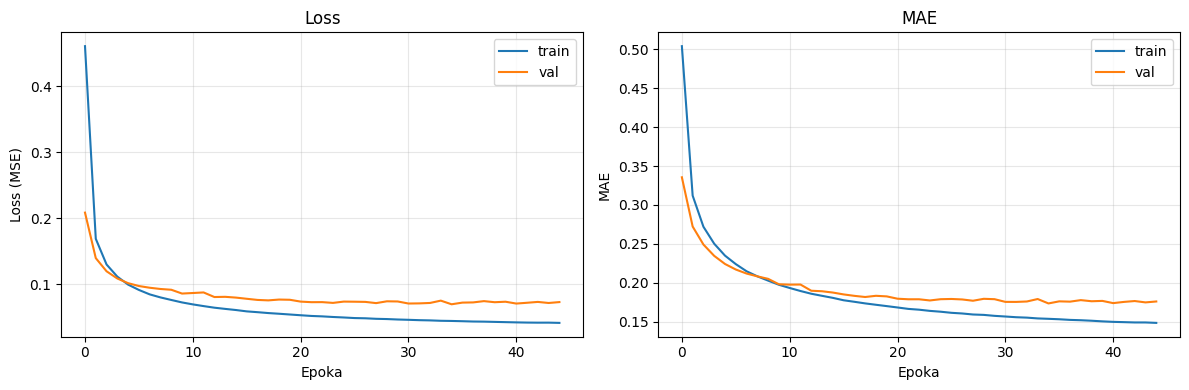

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_v2.history["loss"], label="train")
axes[0].plot(history_v2.history["val_loss"], label="val")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_v2.history["mae"], label="train")
axes[1].plot(history_v2.history["val_mae"], label="val")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Krzywe lepsze od Wariantu 1 - ale typowy lekki overfitting, val loss stabilizuje się na plateau, EarlyStopping przywróci najlepsze wagi.

## 5.19 Ewaluacja Wariantu 2

In [24]:
y_pred_v2_s = lstm_v2.predict([X_val_hist, X_val_future], verbose=0)
n_samples = y_pred_v2_s.shape[0]
y_pred_v2 = scaler_y.inverse_transform(y_pred_v2_s.reshape(-1, len(TARGETS))).reshape(n_samples, HORIZON, len(TARGETS))
y_pred_v2 = np.clip(y_pred_v2, 0, None)

m_lstm_v2 = compute_metrics(y_val, y_pred_v2, "LSTM Wariant 2 (encoder-decoder)")


LSTM Wariant 2 (encoder-decoder)
  wi_MAE: 421.3 MW
  wi_RMSE: 561.7 MW
  pv_MAE: 370.6 MW
  pv_RMSE: 675.3 MW


MAE i RMSE w MW dla Wariantu 2. Porównujemy bezpośrednio z Wariantem 1 i MLP.

**Porównanie z Wariantem 1 i MLP** (val MAE w MW):

| Model | wi | pv | Parametry |
|---|---|---|---|
| MLP | 437 | 373 | 875k |
| LSTM Wariant 1 | **404** | 374 | 682k |
| LSTM Wariant 2 | 421 | **371** | **61k** |

Wariant 1 wygrywa dla wiatru (4% różnica), Wariant 2 wygrywa dla PV (1% różnica) i RMSE w obu kategoriach. Najistotniejsze: **Wariant 2 osiąga porównywalne wyniki przy 11× mniejszej liczbie parametrów** (61k vs 682k). Pokazuje to że architektura encoder-decoder lepiej pasuje do problemu - kompresja semantyczna (osobne sieci dla historii i przyszłej pogody) eliminuje konieczność uczenia się przez sieć "gdzie kończy się historia, a zaczyna prognoza".

Krzywe uczenia Wariantu 2 mają mniejszy gap między train i val niż Wariantu 1 - mniejsza sieć = mniejszy overfitting przy podobnej zdolności predykcyjnej. To dodatkowy argument za wyborem Wariantu 2 jako modelu finalnego.

W bloku 06 jako reprezentanta LSTM puszczamy **Wariant 2** na zbiór testowy z prognozami pogody.

## 5.20 Porównanie modeli — wykres

                wi_MAE  wi_RMSE  pv_MAE  pv_RMSE
MLP              437.3    573.3   373.1    643.2
LSTM Wariant 1   403.7    531.1   374.0    698.4
LSTM Wariant 2   421.3    561.7   370.6    675.3


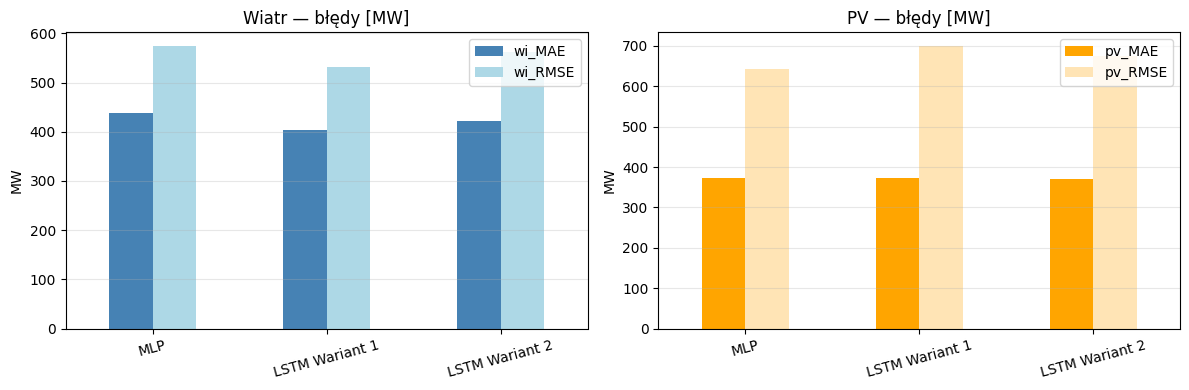

In [25]:
results = pd.DataFrame({
    "MLP":               {"wi_MAE": 437.3, "wi_RMSE": 573.3, "pv_MAE": 373.1, "pv_RMSE": 643.2},
    "LSTM Wariant 1":    m_lstm_v1,
    "LSTM Wariant 2":    m_lstm_v2,
}).T

print(results.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results[["wi_MAE", "wi_RMSE"]].plot(kind="bar", ax=axes[0], color=["steelblue", "lightblue"])
axes[0].set_title("Wiatr — błędy [MW]")
axes[0].set_ylabel("MW")
axes[0].grid(alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=15)

results[["pv_MAE", "pv_RMSE"]].plot(kind="bar", ax=axes[1], color=["orange", "moccasin"])
axes[1].set_title("PV — błędy [MW]")
axes[1].set_ylabel("MW")
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Wszystkie trzy modele bardzo blisko siebie - kwestia wyboru leży w niuansach (Wariant 1 vs Wariant 2 dla różnych targetów) i argumentach pobocznych (rozmiar modelu, overfitting).

## 5.21 Zapis Wariantu 2

Wariant 2 jako finalny model LSTM - zapis modelu i scalerów do użycia w bloku 06.

In [26]:
lstm_v2.save(MODELS_DIR / "lstm.keras")
joblib.dump(scaler_X, MODELS_DIR / "scaler_X_lstm.pkl")
joblib.dump(scaler_y, MODELS_DIR / "scaler_y_lstm.pkl")

predictions_val = pd.DataFrame({
    "timestamp": np.repeat(ts_val, HORIZON),
    "horizon": np.tile(np.arange(HORIZON), len(ts_val)),
    "wi_true": y_val[:, :, 0].flatten(),
    "pv_true": y_val[:, :, 1].flatten(),
    "wi_lstm_v1": y_pred_v1[:, :, 0].flatten(),
    "pv_lstm_v1": y_pred_v1[:, :, 1].flatten(),
    "wi_lstm_v2": y_pred_v2[:, :, 0].flatten(),
    "pv_lstm_v2": y_pred_v2[:, :, 1].flatten(),
})
predictions_val.to_csv(DATA_DIR / "predictions_val_05.csv", sep=";", decimal=",", index=False)

print("zapisane:")
print(f"  {MODELS_DIR / 'lstm.keras'}")
print(f"  {MODELS_DIR / 'scaler_X_lstm.pkl'}, scaler_y_lstm.pkl")
print(f"  {DATA_DIR / 'predictions_val_05.csv'}")

zapisane:
  models/lstm.keras
  models/scaler_X_lstm.pkl, scaler_y_lstm.pkl
  data/processed/predictions_val_05.csv


Model LSTM Wariant 2, scalery, predykcje walidacyjne obu wariantów do `data/processed/predictions_val_05.csv`. W bloku 06 wybierzemy reprezentanta każdej rodziny architektur (baseline, MLP, LSTM) na test końcowy z prognozami pogody.

## Podsumowanie sekcji 5

Dwie architektury LSTM, każda strojona Bayesian Optimization (20 prób, przestrzeń: liczba warstw, neurony, dropout, learning rate):

| Model | wi MAE | pv MAE | Parametry |
|---|---|---|---|
| MLP (z 04) | 437 | 373 | 875k |
| LSTM Wariant 1 (stacked) | **404** | 374 | 682k |
| LSTM Wariant 2 (encoder-decoder) | 421 | **371** | **61k** |

LSTM Wariant 2 wybrany jako finalny model rodziny rekurencyjnej — porównywalne wyniki przy 11× mniejszej liczbie parametrów, mniejszy overfitting, klasyczna architektura forecastingu. W bloku 06 testowany na zbiorze 2025 z prognozami pogody.